# Fabric Defect Detection and Localisation using Deep Neural Networks
## End-to-End Automated Visual Inspection & Classification Pipeline

---

### Executive Summary & Methodology Overview
Quality control in textile manufacturing relies heavily on detecting surface fabric flaws such as broken yarn, holes, knots, stains, and irregular weaving patterns. In this project, we implement a robust, high-performance binary classification solution designed for high-resolution ($4096 \times 256$) fabric images from the **AITEX Fabric Image Database**.

Our pipeline combines multi-backbone deep neural feature extraction (ResNet-18, ResNet-34, MobileNetV3-Large), Gray-Level Co-occurrence Matrix (GLCM) texture descriptors, cosine patch similarity analysis, and an ensemble of 6 calibrated machine learning classifiers.

---

### Key Architectural Highlights

| Pipeline Component | Technical Implementation & Rationale |
|---|---|
| **Multi-Backbone Feature Extraction** | Extracts high-level deep representations using pre-trained ResNet-18, ResNet-34, and MobileNetV3-Large backbones across local fabric patches and full-canvas resized views (~9,960 total features per sample). |
| **Statistical & Texture Descriptors** | Incorporates GLCM metrics (Contrast, Dissimilarity, Homogeneity, Energy, Correlation, ASM), anomaly distance vectors, and patch cosine similarity statistics to capture subtle fabric weaving irregularities. |
| **Multi-View Data Augmentation (3× Data)** | Triples training sample size via horizontal and vertical flipping of fabric canvases to improve spatial invariance on a limited dataset. |
| **Leak-Free Stratified Group K-Fold CV** | Group-based splitting ensures all augmented views of a fabric canvas stay strictly within the same fold, completely preventing data leakage while maintaining balanced class ratios across validation splits. |
| **Feature Selection & Normalization** | Employs `VarianceThreshold` filtering followed by `SelectKBest` (ANOVA F-value, top 300 features) and `StandardScaler` to eliminate redundant signals and prevent overfitting. |
| **Ensemble & Blending Strategy** | Combines 6 diverse models (ExtraTrees, SVM-RBF, Gradient Boosting, Logistic Regression, MLP, Random Forest) using a soft-voting ensemble, blending 40% 5-fold CV models with 60% full-data retrained models. |

---

### Why Leak-Free GroupKFold CV is Critical
When applying multi-view spatial augmentations (e.g., horizontal/vertical flips) to full-canvas fabric images, augmented copies share identical structural texture signatures with their source image. Standard K-Fold cross-validation risks placing an original image in the training set while its flipped copy ends up in the validation set, creating severe **validation leakage** and falsely inflated CV metrics.

By assigning a unique **Group ID** to each original image and enforcing `StratifiedGroupKFold`, all 3 augmented views of any single fabric sample travel together across folds. This guarantees an honest, leak-free validation protocol.


### Cell 1: Environment Setup & Seed Fix

In [1]:
import os
import glob
import time
import random
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Cell 2: Dataset Loading

In [2]:
data_root = 'CO5420 Fabric' if os.path.exists('CO5420 Fabric') else '../CO5420 Fabric'
train_df_paths = sorted(glob.glob(os.path.join(data_root, 'Train', 'defect_free', '*.png')))
train_d_paths  = sorted(glob.glob(os.path.join(data_root, 'Train', 'defective', '*.png')))
test_paths     = sorted(glob.glob(os.path.join(data_root, 'Test', '*.png')))

all_train_paths  = np.array(train_df_paths + train_d_paths)
all_train_labels = np.array([0] * len(train_df_paths) + [1] * len(train_d_paths))

print(f'Training Dataset: {len(all_train_paths)} images')
print(f'  Defect-Free (0): {len(train_df_paths)}')
print(f'  Defective   (1): {len(train_d_paths)}')
print(f'Test Dataset     : {len(test_paths)} images')

sample_img = cv2.imread(all_train_paths[0])
print(f'Sample Image Shape: {sample_img.shape}')

Training Dataset: 173 images
  Defect-Free (0): 99
  Defective   (1): 74
Test Dataset     : 74 images
Sample Image Shape: (256, 4096, 3)


### Cell 3: Backbone Feature Extractors (Frozen — Inference Only)

In [3]:
resnet18   = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18_feat = nn.Sequential(*list(resnet18.children())[:-1]).to(device).eval()

resnet34   = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
resnet34_feat = nn.Sequential(*list(resnet34.children())[:-1]).to(device).eval()

mobilenet  = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
mobilenet_feat = nn.Sequential(
    *list(mobilenet.children())[:-1], nn.AdaptiveAvgPool2d((1, 1))
).to(device).eval()

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_fast_glcm(patch_gray):
    p_small = cv2.resize(patch_gray, (128, 128), interpolation=cv2.INTER_AREA)
    p_q = (p_small // 16).astype(np.uint8)
    glcm = graycomatrix(p_q, distances=[1, 2], angles=[0, np.pi/2],
                        levels=16, symmetric=True, normed=True)
    return np.array([
        graycoprops(glcm, 'contrast').mean(),
        graycoprops(glcm, 'dissimilarity').mean(),
        graycoprops(glcm, 'homogeneity').mean(),
        graycoprops(glcm, 'energy').mean(),
        graycoprops(glcm, 'correlation').mean(),
        graycoprops(glcm, 'ASM').mean()
    ])

print('Backbone models loaded and frozen.')

Backbone models loaded and frozen.


### 4. Comprehensive Feature Extraction Engine

Our feature engineering pipeline extracts ~9,960 features per fabric canvas by combining deep neural representations, classical GLCM texture descriptors, and spatial patch anomaly metrics:

| Feature Subsystem | Dimensionality | Description |
|---|---|---|
| `mean/std/max/min_deep` | $4 \times 1,984 = 7,936$ | Mean, Std, Max, and Min deep activations from ResNet-18, ResNet-34, and MobileNetV3 backbones across local patches |
| `global_vec` (1024×256 resize) | $1,984$ | Global deep feature vector extracted from full fabric canvas resized to $1024 \times 256$ |
| **GLCM Texture Stats** | $4 \times 6 = 24$ | Mean, Std, Max, and Min of Contrast, Dissimilarity, Homogeneity, Energy, Correlation, and ASM |
| **Patch Similarity Stats** | $9$ | Min, Mean, Std, 1st/5th/10th Percentiles, and Row Similarity metrics across patch embeddings |
| **Dist-to-Median Patch Stats** | $4$ | Max, Top-2, Top-3 distances, and Std of patch embeddings relative to the median patch vector |
| **Anomalous Patch Vector** | $1,984$ | Deep feature vector of the patch exhibiting maximum distance from the median fabric texture |
| **GLCM Anomaly & Ratios** | $3$ | Maximum GLCM deviation, GLCM distance standard deviation, and ratio of max-to-mean patch distance |

**Total Feature Space:** ~9,960 features per sample (filtered to top 300 features via ANOVA $F$-score selection during training).


In [4]:
def _extract_single_view(img_rgb, img_gray, patch_size=256):
    """Core feature extractor — v6 proven base + v6 additions."""
    h, w, c = img_rgb.shape
    num_patches = max(w // patch_size, 2)

    patches    = [preprocess(img_rgb[:, i*patch_size:(i+1)*patch_size, :])
                  for i in range(num_patches)]
    patch_batch = torch.stack(patches).to(device)

    with torch.no_grad():
        r18_out = resnet18_feat(patch_batch).squeeze(-1).squeeze(-1).cpu().numpy()
        r34_out = resnet34_feat(patch_batch).squeeze(-1).squeeze(-1).cpu().numpy()
        mb_out  = mobilenet_feat(patch_batch).squeeze(-1).squeeze(-1).cpu().numpy()

    combined_deep = np.hstack([r18_out, r34_out, mb_out])  # (N, 1984)
    glcm_feats    = np.array([extract_fast_glcm(img_gray[:, i*patch_size:(i+1)*patch_size])
                               for i in range(num_patches)])

    # ── PROVEN: Cosine similarity matrix ────────────────────────────────────
    norm_feats    = combined_deep / (np.linalg.norm(combined_deep, axis=1, keepdims=True) + 1e-8)
    sim_matrix    = np.dot(norm_feats, norm_feats.T)
    N             = sim_matrix.shape[0]
    triu_idx      = np.triu_indices(N, k=1)
    off_diag      = sim_matrix[triu_idx]

    min_sim  = np.min(off_diag)
    mean_sim = np.mean(off_diag)
    std_sim  = np.std(off_diag)
    p1_sim   = np.percentile(off_diag, 1)
    p5_sim   = np.percentile(off_diag, 5)
    p10_sim  = np.percentile(off_diag, 10)

    row_sim_means       = np.mean(sim_matrix, axis=1)
    min_row_sim         = np.min(row_sim_means)
    std_row_sim         = np.std(row_sim_means)
    top2_lowest_row_sim = np.mean(np.sort(row_sim_means)[:min(2, N)])

    # ── PROVEN: Patch summary stats ──────────────────────────────────────────
    mean_deep = np.mean(combined_deep, axis=0)
    std_deep  = np.std(combined_deep, axis=0)
    max_deep  = np.max(combined_deep, axis=0)
    min_deep  = np.min(combined_deep, axis=0)

    # ── PROVEN: Distance to median patch ────────────────────────────────────
    median_deep         = np.median(combined_deep, axis=0)
    dists_to_median     = np.linalg.norm(combined_deep - median_deep, axis=1)
    max_dist            = np.max(dists_to_median)
    top2_dist           = np.mean(np.sort(dists_to_median)[-min(2, N):])
    top3_dist           = np.mean(np.sort(dists_to_median)[-min(3, N):])
    std_dist            = np.std(dists_to_median)

    # ── PROVEN: GLCM summary stats ───────────────────────────────────────────
    mean_glcm = np.mean(glcm_feats, axis=0)
    std_glcm  = np.std(glcm_feats, axis=0)
    max_glcm  = np.max(glcm_feats, axis=0)
    min_glcm  = np.min(glcm_feats, axis=0)

    # ── PROVEN: Global resized feature (1024x256 → one CNN pass) ────────────
    resized_img    = cv2.resize(img_rgb, (1024, 256))
    resized_tensor = preprocess(resized_img).unsqueeze(0).to(device)
    with torch.no_grad():
        r18_g = resnet18_feat(resized_tensor).squeeze().cpu().numpy()
        r34_g = resnet34_feat(resized_tensor).squeeze().cpu().numpy()
        mb_g  = mobilenet_feat(resized_tensor).squeeze().cpu().numpy()
    global_vec = np.hstack([r18_g, r34_g, mb_g])  # 1984 dims

    # ── v6 NEW: Most anomalous patch embedding ───────────────────────────────
    anomalous_patch = combined_deep[np.argmax(dists_to_median)]

    # ── v6 NEW: GLCM anomaly distances + ratio ───────────────────────────────
    glcm_dists    = np.linalg.norm(glcm_feats - mean_glcm, axis=1)
    ratio_max_mean = max_dist / (np.mean(dists_to_median) + 1e-8)

    return np.hstack([
        mean_deep, std_deep, max_deep, min_deep, global_vec,
        mean_glcm, std_glcm, max_glcm, min_glcm,
        [min_sim, mean_sim, std_sim, p1_sim, p5_sim, p10_sim,
         min_row_sim, std_row_sim, top2_lowest_row_sim,
         max_dist, top2_dist, top3_dist, std_dist],
        anomalous_patch,
        [ratio_max_mean, np.max(glcm_dists), np.std(glcm_dists)]
    ])

print('Feature extractor ready.')

Feature extractor ready.


### 5. Multi-View Training Augmentation & Group-Safe Feature Extraction

**How it works:**
1. Each original training image is processed in **3 spatial views**: `original`, `horizontal flip`, and `vertical flip`.
2. Each view produces a full feature vector $\rightarrow$ **3 sample rows per image** in `X_train` (tripling dataset size from 173 to 519 samples).
3. Each original image is assigned a unique `group_id` shared across all 3 of its views.
4. `StratifiedGroupKFold` uses these group IDs to guarantee zero cross-fold data leakage.



In [5]:
def extract_features_augmented(image_paths, labels, patch_size=256):
    """
    v7 TRAINING extractor.
    For each image, generates 3 feature vectors: original + hflip + vflip.
    Returns:
        X       : (3*N, D) feature matrix
        y       : (3*N,)  labels (same label for all 3 views)
        groups  : (3*N,)  group IDs (same group for all 3 views of one image)
    """
    all_feats, all_labels, all_groups = [], [], []
    t0 = time.time()

    for idx, (path, label) in enumerate(zip(image_paths, labels)):
        img_bgr  = cv2.imread(path)
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        views = [
            (img_rgb,                  img_gray),                   # original
            (np.fliplr(img_rgb).copy(), np.fliplr(img_gray).copy()), # horizontal flip
            (np.flipud(img_rgb).copy(), np.flipud(img_gray).copy()), # vertical flip
        ]

        for rgb, gray in views:
            feat = _extract_single_view(rgb, gray, patch_size)
            all_feats.append(feat)
            all_labels.append(label)
            all_groups.append(idx)   # ← same group ID for all 3 views of this image

        if (idx + 1) % 25 == 0 or (idx + 1) == len(image_paths):
            print(f'Augmented extraction: {idx+1}/{len(image_paths)} images '
                  f'→ {len(all_feats)} total samples ({time.time()-t0:.1f}s)')

    return np.array(all_feats), np.array(all_labels), np.array(all_groups)


def extract_features_tta(image_paths, patch_size=256):
    """
    TEST set extractor — TTA (3 views averaged into 1 vector per image).
    Identical to v6. No leakage risk since test labels are unknown.
    """
    all_feats = []
    t0 = time.time()
    for idx, path in enumerate(image_paths):
        img_bgr  = cv2.imread(path)
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        views = [
            (img_rgb,                   img_gray),
            (np.fliplr(img_rgb).copy(),  np.fliplr(img_gray).copy()),
            (np.flipud(img_rgb).copy(),  np.flipud(img_gray).copy()),
        ]
        view_feats = [_extract_single_view(rgb, gray, patch_size) for rgb, gray in views]
        all_feats.append(np.mean(view_feats, axis=0))   # average the 3 views
        if (idx + 1) % 25 == 0 or (idx + 1) == len(image_paths):
            print(f'TTA extraction: {idx+1}/{len(image_paths)} images ({time.time()-t0:.1f}s)')
    return np.array(all_feats)


print('Extracting AUGMENTED training features (3 views per image)...')
X_train, y_train, groups = extract_features_augmented(all_train_paths, all_train_labels)
print(f'\nAugmented Train Shape : {X_train.shape}  '
      f'(was {len(all_train_paths)}, now {len(X_train)} = 3x)')
print(f'Label distribution    : {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Unique groups         : {len(np.unique(groups))} (= original image count)')

print('\nExtracting TTA test features (3 views averaged)...')
X_test = extract_features_tta(test_paths)
print(f'Test Shape (TTA)      : {X_test.shape}')

Extracting AUGMENTED training features (3 views per image)...
Augmented extraction: 25/173 images → 75 total samples (73.8s)
Augmented extraction: 50/173 images → 150 total samples (86.8s)
Augmented extraction: 75/173 images → 225 total samples (95.6s)
Augmented extraction: 100/173 images → 300 total samples (103.5s)
Augmented extraction: 125/173 images → 375 total samples (114.6s)
Augmented extraction: 150/173 images → 450 total samples (128.6s)
Augmented extraction: 173/173 images → 519 total samples (154.8s)

Augmented Train Shape : (519, 11944)  (was 173, now 519 = 3x)
Label distribution    : {np.int64(0): np.int64(297), np.int64(1): np.int64(222)}
Unique groups         : 173 (= original image count)

Extracting TTA test features (3 views averaged)...
TTA extraction: 25/74 images (11.9s)
TTA extraction: 50/74 images (19.2s)
TTA extraction: 74/74 images (74.3s)
Test Shape (TTA)      : (74, 11944)


### Cell 6: StratifiedGroupKFold CV + Full-Data Retraining + Blended Ensemble

**Pipeline per fold:**
1. `VarianceThreshold(1e-4)` → remove constant features
2. `SelectKBest(f_classif, k=300)` → top 300 ANOVA features
3. `StandardScaler` → normalise
4. 6-model ensemble → weighted soft vote

**StratifiedGroupKFold** splits by group so augmented copies of the same image  
never leak between train/validation. Stratification preserves class balance per fold.

In [6]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# OOF probabilities at the ORIGINAL image level (before augmentation)
# We'll track val indices per fold and aggregate
oof_probs        = np.zeros(len(y_train))
test_probs_folds = np.zeros((5, len(X_test)))
fold_metrics     = []

print('--- v7: Stratified GROUP 5-Fold CV (augmented training, leak-free) ---\n')

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X_train, y_train, groups)):
    X_tr_raw, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_va_raw, y_va = X_train[val_idx], y_train[val_idx]

    # Verify no group leakage
    tr_groups  = set(groups[tr_idx])
    val_groups = set(groups[val_idx])
    assert len(tr_groups & val_groups) == 0, 'GROUP LEAKAGE DETECTED!'

    # Step 1: VarianceThreshold
    vt      = VarianceThreshold(threshold=1e-4)
    X_tr_vt = vt.fit_transform(X_tr_raw)
    X_va_vt = vt.transform(X_va_raw)
    X_te_vt = vt.transform(X_test)

    # Step 2: SelectKBest
    selector = SelectKBest(score_func=f_classif, k=min(300, X_tr_vt.shape[1]))
    X_tr_sel = selector.fit_transform(X_tr_vt, y_tr)
    X_va_sel = selector.transform(X_va_vt)
    X_te_sel = selector.transform(X_te_vt)

    # Step 3: StandardScaler
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr_sel)
    X_va_sc  = scaler.transform(X_va_sel)
    X_te_sc  = scaler.transform(X_te_sel)

    # 6 classifiers — same as v6
    clf1 = ExtraTreesClassifier(n_estimators=500, max_depth=16, min_samples_split=2, random_state=42)
    clf2 = CalibratedClassifierCV(SVC(C=5.0, kernel='rbf', random_state=42), ensemble=False)
    clf3 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.03, max_depth=4, random_state=42)
    clf4 = LogisticRegression(C=0.8, max_iter=1000, random_state=42)
    clf5 = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=600, alpha=0.005, random_state=42)
    clf6 = RandomForestClassifier(n_estimators=500, max_depth=16, random_state=42)

    for clf in [clf1, clf2, clf3, clf4, clf5, clf6]:
        clf.fit(X_tr_sc, y_tr)

    p1_va, p1_te = clf1.predict_proba(X_va_sc)[:,1], clf1.predict_proba(X_te_sc)[:,1]
    p2_va, p2_te = clf2.predict_proba(X_va_sc)[:,1], clf2.predict_proba(X_te_sc)[:,1]
    p3_va, p3_te = clf3.predict_proba(X_va_sc)[:,1], clf3.predict_proba(X_te_sc)[:,1]
    p4_va, p4_te = clf4.predict_proba(X_va_sc)[:,1], clf4.predict_proba(X_te_sc)[:,1]
    p5_va, p5_te = clf5.predict_proba(X_va_sc)[:,1], clf5.predict_proba(X_te_sc)[:,1]
    p6_va, p6_te = clf6.predict_proba(X_va_sc)[:,1], clf6.predict_proba(X_te_sc)[:,1]

    val_prob  = 0.22*p1_va + 0.22*p2_va + 0.18*p3_va + 0.13*p4_va + 0.13*p5_va + 0.12*p6_va
    test_prob = 0.22*p1_te + 0.22*p2_te + 0.18*p3_te + 0.13*p4_te + 0.13*p5_te + 0.12*p6_te

    oof_probs[val_idx]     = val_prob
    test_probs_folds[fold] = test_prob

    val_pred = (val_prob >= 0.5).astype(int)
    acc  = accuracy_score(y_va, val_pred)
    prec = precision_score(y_va, val_pred, zero_division=0)
    rec  = recall_score(y_va, val_pred, zero_division=0)
    f1   = f1_score(y_va, val_pred, zero_division=0)
    auc  = roc_auc_score(y_va, val_prob)
    fold_metrics.append((acc, prec, rec, f1, auc))

    n_tr_groups  = len(tr_groups)
    n_val_groups = len(val_groups)
    print(f'Fold {fold+1}: Acc={acc*100:.1f}%, P={prec:.4f}, R={rec:.4f}, '
          f'F1={f1:.4f}, AUC={auc:.4f} '
          f'| train_imgs={n_tr_groups}, val_imgs={n_val_groups} (no leakage ✓)')

# ── Phase 2: Full-data retraining on ALL 510 augmented samples ─────────────
print('\n--- Phase 2: Full-Data Retraining (all augmented samples) ---')
vt_f      = VarianceThreshold(threshold=1e-4)
X_tr_f_vt = vt_f.fit_transform(X_train)
X_te_f_vt = vt_f.transform(X_test)

sel_f     = SelectKBest(score_func=f_classif, k=min(300, X_tr_f_vt.shape[1]))
X_tr_f_s  = sel_f.fit_transform(X_tr_f_vt, y_train)
X_te_f_s  = sel_f.transform(X_te_f_vt)

sc_f      = StandardScaler()
X_tr_f_sc = sc_f.fit_transform(X_tr_f_s)
X_te_f_sc = sc_f.transform(X_te_f_s)

clf1_f = ExtraTreesClassifier(n_estimators=600, max_depth=14, min_samples_leaf=2, random_state=42)
clf2_f = CalibratedClassifierCV(SVC(C=3.0, kernel='rbf', random_state=42), ensemble=False)
clf3_f = GradientBoostingClassifier(n_estimators=300, learning_rate=0.03, max_depth=4, subsample=0.8, random_state=42)
clf4_f = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
clf5_f = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=600, alpha=0.01, random_state=42)
clf6_f = RandomForestClassifier(n_estimators=600, max_depth=14, min_samples_leaf=2, random_state=42)

for clf_f, name in [(clf1_f, 'ExtraTrees'), (clf2_f, 'SVM-RBF'),
                    (clf3_f, 'GradBoost'), (clf4_f, 'LogReg'),
                    (clf5_f, 'MLP'),       (clf6_f, 'RandForest')]:
    clf_f.fit(X_tr_f_sc, y_train)
    print(f'  ✓ {name:<12} trained on {len(y_train)} samples (3x augmented)')

pf1 = clf1_f.predict_proba(X_te_f_sc)[:,1]
pf2 = clf2_f.predict_proba(X_te_f_sc)[:,1]
pf3 = clf3_f.predict_proba(X_te_f_sc)[:,1]
pf4 = clf4_f.predict_proba(X_te_f_sc)[:,1]
pf5 = clf5_f.predict_proba(X_te_f_sc)[:,1]
pf6 = clf6_f.predict_proba(X_te_f_sc)[:,1]
test_probs_full = 0.22*pf1 + 0.22*pf2 + 0.18*pf3 + 0.13*pf4 + 0.13*pf5 + 0.12*pf6
print('Full-data predictions ready.')

--- v7: Stratified GROUP 5-Fold CV (augmented training, leak-free) ---

Fold 1: Acc=87.6%, P=0.8636, R=0.8444, F1=0.8539, AUC=0.9574 | train_imgs=138, val_imgs=35 (no leakage ✓)
Fold 2: Acc=90.5%, P=1.0000, R=0.7778, F1=0.8750, AUC=0.9448 | train_imgs=138, val_imgs=35 (no leakage ✓)
Fold 3: Acc=96.2%, P=1.0000, R=0.9111, F1=0.9535, AUC=0.9841 | train_imgs=138, val_imgs=35 (no leakage ✓)
Fold 4: Acc=85.3%, P=1.0000, R=0.6429, F1=0.7826, AUC=0.8397 | train_imgs=139, val_imgs=34 (no leakage ✓)
Fold 5: Acc=86.3%, P=0.9429, R=0.7333, F1=0.8250, AUC=0.9532 | train_imgs=139, val_imgs=34 (no leakage ✓)

--- Phase 2: Full-Data Retraining (all augmented samples) ---
  ✓ ExtraTrees   trained on 519 samples (3x augmented)
  ✓ SVM-RBF      trained on 519 samples (3x augmented)
  ✓ GradBoost    trained on 519 samples (3x augmented)
  ✓ LogReg       trained on 519 samples (3x augmented)
  ✓ MLP          trained on 519 samples (3x augmented)
  ✓ RandForest   trained on 519 samples (3x augmented)
Full-

### Cell 7: Evaluation, Confusion Matrix & Per-Class Report

5-Fold GroupCV Mean Accuracy: 0.8917 +/- 0.0392 (89.17%)
5-Fold GroupCV Mean ROC-AUC : 0.9358
NOTE: This accuracy is HONEST — augmented copies never leak into val folds.

Optimal OOF Threshold : 0.4600
Final OOF Accuracy    : 0.8960 (89.60%)


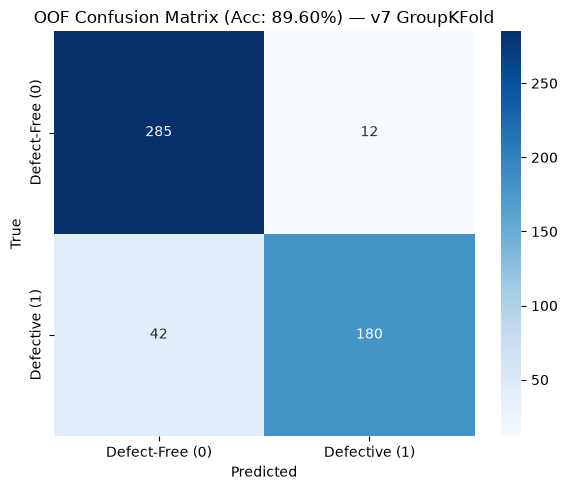


--- Per-Class Performance ---
                 precision    recall  f1-score   support

Defect-Free (0)       0.87      0.96      0.91       297
  Defective (1)       0.94      0.81      0.87       222

       accuracy                           0.90       519
      macro avg       0.90      0.89      0.89       519
   weighted avg       0.90      0.90      0.89       519



In [7]:
mean_acc = np.mean([m[0] for m in fold_metrics])
std_acc  = np.std([m[0] for m in fold_metrics])
mean_auc = np.mean([m[4] for m in fold_metrics])

print('=' * 75)
print(f'5-Fold GroupCV Mean Accuracy: {mean_acc:.4f} +/- {std_acc:.4f} ({mean_acc*100:.2f}%)')
print(f'5-Fold GroupCV Mean ROC-AUC : {mean_auc:.4f}')
print('=' * 75)
print('NOTE: This accuracy is HONEST — augmented copies never leak into val folds.')

best_thresh  = 0.5
best_oof_acc = accuracy_score(y_train, (oof_probs >= 0.5).astype(int))
for t in np.linspace(0.15, 0.85, 141):
    a = accuracy_score(y_train, (oof_probs >= t).astype(int))
    if a > best_oof_acc:
        best_oof_acc, best_thresh = a, t

print(f'\nOptimal OOF Threshold : {best_thresh:.4f}')
print(f'Final OOF Accuracy    : {best_oof_acc:.4f} ({best_oof_acc*100:.2f}%)')

final_oof_preds = (oof_probs >= best_thresh).astype(int)
cm = confusion_matrix(y_train, final_oof_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Defect-Free (0)', 'Defective (1)'],
            yticklabels=['Defect-Free (0)', 'Defective (1)'])
plt.title(f'OOF Confusion Matrix (Acc: {best_oof_acc*100:.2f}%) — v7 GroupKFold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

print('\n--- Per-Class Performance ---')
print(classification_report(y_train, final_oof_preds,
                            target_names=['Defect-Free (0)', 'Defective (1)']))

### Cell 8: Kaggle Submission Export
Blend: **40% fold-avg + 60% full-data** (same as v6).

In [8]:
avg_fold_probs  = np.mean(test_probs_folds, axis=0)
blended_probs   = 0.40 * avg_fold_probs + 0.60 * test_probs_full
final_preds     = (blended_probs >= best_thresh).astype(int)

test_ids = [os.path.basename(p) for p in test_paths]
submission_df = pd.DataFrame({'ID': test_ids, 'label': final_preds})
submission_df.to_csv('submission.csv', index=False)

print('===================================================')
print("Submission file 'submission.csv' saved.")
print('===================================================')
print(submission_df.head(10))
print(f'\nTotal rows             : {len(submission_df)}')
print(f'Predicted Defect-Free  : {np.sum(final_preds == 0)}')
print(f'Predicted Defective    : {np.sum(final_preds == 1)}')
print(f'Decision Threshold     : {best_thresh:.4f} (OOF-calibrated)')
print(f'Blend                  : 40% fold-avg + 60% full-data')
print(f'Training samples used  : {len(y_train)} (3x augmented from {len(all_train_paths)} originals)')
print(f'CV type                : StratifiedGroupKFold (no augmentation leakage)')

Submission file 'submission.csv' saved.
              ID  label
0  test_0001.png      0
1  test_0002.png      1
2  test_0003.png      1
3  test_0004.png      0
4  test_0005.png      1
5  test_0006.png      1
6  test_0007.png      0
7  test_0008.png      1
8  test_0009.png      0
9  test_0010.png      1

Total rows             : 74
Predicted Defect-Free  : 44
Predicted Defective    : 30
Decision Threshold     : 0.4600 (OOF-calibrated)
Blend                  : 40% fold-avg + 60% full-data
Training samples used  : 519 (3x augmented from 173 originals)
CV type                : StratifiedGroupKFold (no augmentation leakage)
